# **Cálculo simbólico con `sympy`**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franperezec/propedeutico-flacso/blob/main/clases/calculo_simbolico/reglas_derivacion_sympy.ipynb)

**Profesor:** Francisco Pérez M. · **Propedéutico de Matemáticas y Programación · FLACSO Ecuador**

Límites, derivación simbólica, series de Taylor y aplicaciones económicas.


## 1. Configuración inicial

In [1]:
import sympy as sp
from sympy import init_printing

init_printing(use_latex='mathjax')

x, y, z, t = sp.symbols('x y z t', real=True)

x, y, z, t

(x, y, z, t)

## 2. Operaciones básicas y funciones útiles

### 2.1 Simplificación

Para $x\neq 1$:

$$
\frac{x^2-1}{x-1}=x+1.
$$

In [2]:
expresion = (x**2 - 1) / (x - 1)
expresion_simplificada = sp.simplify(expresion)

display(expresion)
display(expresion_simplificada)

 2    
x  - 1
──────
x - 1 

x + 1

### 2.2 Expansión y factorización

$$
(x+y)^3=x^3+3x^2y+3xy^2+y^3,
$$

$$
x^3-4x=x(x-2)(x+2).
$$

In [3]:
potencia = (x + y)**3
potencia_expandida = sp.expand(potencia)

polinomio = x**3 - 4*x
polinomio_factorizado = sp.factor(polinomio)

display(potencia_expandida)
display(polinomio_factorizado)

 3      2          2    3
x  + 3⋅x ⋅y + 3⋅x⋅y  + y 

x⋅(x - 2)⋅(x + 2)

### 2.3 Logaritmos y exponenciales

Función de utilidad logarítmica, con $x>0$ y $y>0$:

$$
U(x,y)=\alpha\ln(x)+\beta\ln(y).
$$

Función de producción con saturación temporal, con $A>0$ y $k>0$:

$$
Q(t)=A\left(1-e^{-kt}\right).
$$

In [4]:
alpha, beta, A, k = sp.symbols('alpha beta A k', positive=True)

U = alpha*sp.log(x) + beta*sp.log(y)
U_combinada = sp.logcombine(U, force=True)

Q = A*(1 - sp.exp(-k*t))

display(U)
display(U_combinada)
display(Q)

α⋅log(x) + β⋅log(y)

   ⎛ α  β⎞
log⎝x ⋅y ⎠

  ⎛     -k⋅t⎞
A⋅⎝1 - ℯ    ⎠

## 3. Límites

### 3.1 Límites estándar

$$
\lim_{x\to 0}\frac{\sin(x)}{x}=1,
$$

$$
\lim_{x\to\infty}\left(1+\frac{1}{x}\right)^x=e.
$$

In [5]:
limite_seno = sp.limit(sp.sin(x)/x, x, 0)
limite_exponencial = sp.limit((1 + 1/x)**x, x, sp.oo)

display(limite_seno)
display(limite_exponencial)

1

ℯ

### 3.2 Límites laterales

$$
\lim_{x\to 0^-}\frac{1}{x}=-\infty,
$$

$$
\lim_{x\to 0^+}\frac{1}{x}=+\infty.
$$

In [6]:
limite_izquierdo = sp.limit(1/x, x, 0, dir='-')
limite_derecho = sp.limit(1/x, x, 0, dir='+')

display(limite_izquierdo)
display(limite_derecho)

-∞

∞

## 4. Derivada por definición

Sea

$$
f(x)=x^3-2x^2+x.
$$

La derivada se obtiene mediante

$$
f'(x)=\lim_{h\to 0}\frac{f(x+h)-f(x)}{h}.
$$

In [7]:
h = sp.symbols('h', real=True)

f = x**3 - 2*x**2 + x
f_x_mas_h = sp.expand(f.subs(x, x + h))
incremento = sp.expand(f_x_mas_h - f)
cociente_incremental = sp.cancel(incremento / h)
derivada_por_definicion = sp.limit(cociente_incremental, h, 0)

print("1. f(x)")
display(f)

print("2. f(x+h)")
display(f_x_mas_h)

print("3. f(x+h) - f(x)")
display(incremento)

print("4. [f(x+h) - f(x)] / h")
display(cociente_incremental)

print("5. Límite cuando h → 0")
display(derivada_por_definicion)

1. f(x)


 3      2    
x  - 2⋅x  + x

2. f(x+h)


 3      2        2        2                3      2    
h  + 3⋅h ⋅x - 2⋅h  + 3⋅h⋅x  - 4⋅h⋅x + h + x  - 2⋅x  + x

3. f(x+h) - f(x)


 3      2        2        2            
h  + 3⋅h ⋅x - 2⋅h  + 3⋅h⋅x  - 4⋅h⋅x + h

4. [f(x+h) - f(x)] / h


 2                    2          
h  + 3⋅h⋅x - 2⋅h + 3⋅x  - 4⋅x + 1

5. Límite cuando h → 0


   2          
3⋅x  - 4⋅x + 1

## 5. Reglas de derivación

### 5.1 Regla del producto

Para $x>0$, sea

$$
f(x)=x^2\ln(x).
$$

La regla del producto establece

$$
\frac{d}{dx}\left[u(x)v(x)\right]
=
u'(x)v(x)+u(x)v'(x).
$$

Por tanto,

$$
f'(x)=2x\ln(x)+x
=x\left(2\ln(x)+1\right).
$$


In [8]:
f_producto = x**2 * sp.log(x)

derivada_producto = sp.diff(f_producto, x)
derivada_producto_factorizada = sp.factor(derivada_producto)

u_producto = x**2
v_producto = sp.log(x)
derivada_producto_regla = (
    sp.diff(u_producto, x) * v_producto
    + u_producto * sp.diff(v_producto, x)
)

verificacion_producto = sp.simplify(
    derivada_producto - derivada_producto_regla
)

display(f_producto)
display(derivada_producto)
display(derivada_producto_factorizada)
display(verificacion_producto)

 2       
x ⋅log(x)

2⋅x⋅log(x) + x

x⋅(2⋅log(x) + 1)

0

### 5.2 Regla del cociente: costo medio

Sea $q>0$ y la función de costo total

$$
C(q)=F+cq+dq^2.
$$

El costo medio es

$$
CMe(q)=\frac{C(q)}{q}.
$$

La regla del cociente establece

$$
\frac{d}{dq}\left[\frac{u(q)}{v(q)}\right]
=
\frac{u'(q)v(q)-u(q)v'(q)}{v(q)^2}.
$$

Por tanto,

$$
CMe'(q)
=
\frac{qC'(q)-C(q)}{q^2}
=
d-\frac{F}{q^2}.
$$


In [9]:
q, F, c, d = sp.symbols('q F c d', positive=True)

costo_total = F + c*q + d*q**2
costo_medio = costo_total / q

derivada_costo_medio = sp.simplify(
    sp.diff(costo_medio, q)
)

derivada_cociente_regla = sp.simplify(
    (
        sp.diff(costo_total, q) * q
        - costo_total * sp.diff(q, q)
    ) / q**2
)

verificacion_cociente = sp.simplify(
    derivada_costo_medio - derivada_cociente_regla
)

display(costo_total)
display(costo_medio)
display(derivada_costo_medio)
display(derivada_cociente_regla)
display(verificacion_cociente)

             2
F + c⋅q + d⋅q 

             2
F + c⋅q + d⋅q 
──────────────
      q       

  F     
- ── + d
   2    
  q     

  F     
- ── + d
   2    
  q     

0

### 5.3 Regla de la cadena

Considere el costo con componente no lineal

$$
C(q)=e^{0.5q^2}.
$$

Si

$$
u(q)=0.5q^2,
\qquad
C(q)=e^{u(q)},
$$

la regla de la cadena establece

$$
C'(q)
=
\frac{dC}{du}\frac{du}{dq}.
$$

Por tanto,

$$
C'(q)
=
e^{0.5q^2}q
=
qe^{0.5q^2}.
$$


In [10]:
exponente_costo = sp.Rational(1, 2) * q**2
costo_compuesto = sp.exp(exponente_costo)

derivada_cadena = sp.diff(costo_compuesto, q)
derivada_cadena_regla = (
    sp.exp(exponente_costo)
    * sp.diff(exponente_costo, q)
)

verificacion_cadena = sp.simplify(
    derivada_cadena - derivada_cadena_regla
)

display(costo_compuesto)
display(derivada_cadena)
display(derivada_cadena_regla)
display(verificacion_cadena)

  2
 q 
 ──
 2 
ℯ  

    2
   q 
   ──
   2 
q⋅ℯ  

    2
   q 
   ──
   2 
q⋅ℯ  

0

## 6. Series de Taylor

### 6.1 Polinomio de Taylor con `sp.series`

Las derivadas que ya sabemos calcular permiten aproximar una función alrededor de un punto $x_0$ mediante un polinomio. El **polinomio de Taylor de grado $m$** de $f$ en $x_0$ es

$$
P_m(x)
=
\sum_{k=0}^{m}\frac{f^{(k)}(x_0)}{k!}(x-x_0)^k
=
f(x_0)+f'(x_0)(x-x_0)+\cdots+\frac{f^{(m)}(x_0)}{m!}(x-x_0)^m.
$$

En economía, la aproximación más usada es la de $\ln(1+r)$ en $r_0=0$: si $r$ es una tasa de crecimiento o de interés pequeña,

$$
\ln(1+r)\approx r.
$$

Por eso las diferencias logarítmicas se interpretan como tasas de crecimiento:

$$
\ln(Y_t)-\ln(Y_{t-1})=\ln(1+g)\approx g.
$$

En SymPy, `sp.series(f, x, x0, n)` desarrolla la serie e incluye el resto en **notación O-grande**, $O\!\left((x-x_0)^n\right)$.

**Cuidado con el parámetro `n`:** indica el orden del resto, no el grado del polinomio. Con `n = 3` se obtienen los términos hasta $x^2$ más $O(x^3)$, es decir, el polinomio de Taylor de grado $2$. El método `.removeO()` elimina el término $O$ y deja solo el polinomio.

In [11]:
funcion_log = sp.log(1 + x)

serie_log = sp.series(funcion_log, x, 0, 3)
polinomio_taylor_2 = serie_log.removeO()

display(funcion_log)
display(serie_log)
display(polinomio_taylor_2)

log(x + 1)

     2        
    x     ⎛ 3⎞
x - ── + O⎝x ⎠
    2         

   2    
  x     
- ── + x
  2     

### 6.2 Verificación con derivadas y factoriales

El polinomio de grado $2$ en $x_0=0$ se construye a mano con las derivadas de las secciones anteriores:

$$
P_2(x)
=
f(0)+f'(0)\,x+\frac{f''(0)}{2!}\,x^2.
$$

Para $f(x)=\ln(1+x)$: $f(0)=0$, $f'(0)=1$ y $f''(0)=-1$, de modo que

$$
P_2(x)=x-\frac{x^2}{2}.
$$

La diferencia entre el polinomio de `sp.series` y el construido a mano debe simplificarse a $0$.

In [12]:
derivada_log_1 = sp.diff(funcion_log, x)
derivada_log_2 = sp.diff(funcion_log, x, 2)

polinomio_manual = (
    funcion_log.subs(x, 0)
    + derivada_log_1.subs(x, 0) * x
    + derivada_log_2.subs(x, 0) / sp.factorial(2) * x**2
)

verificacion_taylor = sp.simplify(polinomio_taylor_2 - polinomio_manual)

display(polinomio_manual)
display(verificacion_taylor)

   2    
  x     
- ── + x
  2     

0

### 6.3 Error numérico de la aproximación

¿Qué tan buena es $\ln(1+r)\approx r$? Comparamos el valor exacto con las aproximaciones de grado $1$ y grado $2$ para tasas típicas de la región: un crecimiento del PIB de $2\%$, una inflación de $5\%$, una tasa de interés activa de $10\%$ y una tasa extrema de $50\%$.

$$
\text{error}_m(r)=\left|\ln(1+r)-P_m(r)\right|.
$$

In [13]:
polinomio_taylor_1 = x

for tasa in [0.02, 0.05, 0.10, 0.50]:
    valor_exacto = sp.log(1 + tasa)
    error_grado_1 = abs(valor_exacto - polinomio_taylor_1.subs(x, tasa))
    error_grado_2 = abs(valor_exacto - polinomio_taylor_2.subs(x, tasa))
    print(
        f"r = {tasa:.2f} | ln(1+r) = {float(valor_exacto):.6f} | "
        f"error grado 1 = {float(error_grado_1):.6f} | "
        f"error grado 2 = {float(error_grado_2):.6f}"
    )

r = 0.02 | ln(1+r) = 0.019803 | error grado 1 = 0.000197 | error grado 2 = 0.000003
r = 0.05 | ln(1+r) = 0.048790 | error grado 1 = 0.001210 | error grado 2 = 0.000040
r = 0.10 | ln(1+r) = 0.095310 | error grado 1 = 0.004690 | error grado 2 = 0.000310
r = 0.50 | ln(1+r) = 0.405465 | error grado 1 = 0.094535 | error grado 2 = 0.030465


### 6.4 Gráfica: función frente a polinomios de Taylor

El crecimiento continuo usa la función exponencial: un capital $A$ que crece a una tasa $r$ durante $t$ años vale $Ae^{rt}$ (interés compuesto continuo). Aproximamos $e^x$ en $x_0=0$ con polinomios de grado creciente:

$$
P_1(x)=1+x,
\qquad
P_2(x)=1+x+\frac{x^2}{2},
\qquad
P_4(x)=1+x+\frac{x^2}{2}+\frac{x^3}{6}+\frac{x^4}{24}.
$$

`sp.lambdify` convierte cada expresión simbólica en una función numérica para poder graficarla.

**Qué observar:** cerca de $x_0=0$ las cuatro curvas casi coinciden; al alejarse del punto base, los polinomios de mayor grado acompañan a $e^x$ durante más tramo. $P_1$ es la recta tangente en $x_0=0$.

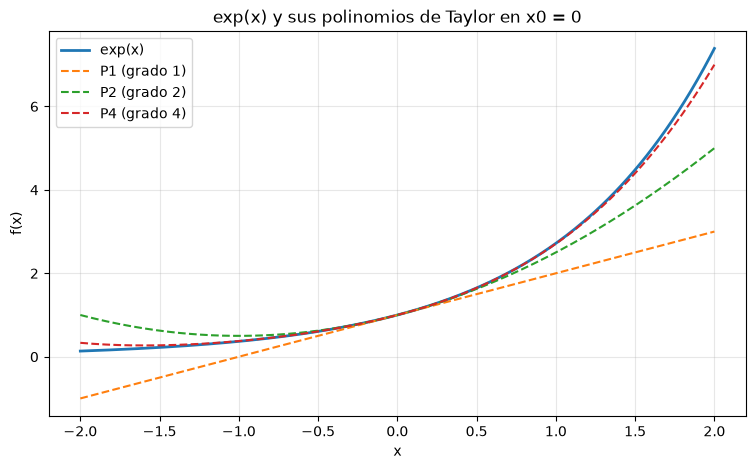

In [14]:
# numpy y matplotlib se usan solo en esta celda; por eso se importan aquí
# y no en la configuración inicial (el resto del notebook es simbólico).
import numpy as np
import matplotlib.pyplot as plt

funcion_exp = sp.exp(x)

# Recuerde: en sp.series el parámetro n es el orden del resto,
# de modo que el grado del polinomio es n - 1.
polinomio_grado_1 = sp.series(funcion_exp, x, 0, 2).removeO()
polinomio_grado_2 = sp.series(funcion_exp, x, 0, 3).removeO()
polinomio_grado_4 = sp.series(funcion_exp, x, 0, 5).removeO()

funcion_np = sp.lambdify(x, funcion_exp, 'numpy')
p1_np = sp.lambdify(x, polinomio_grado_1, 'numpy')
p2_np = sp.lambdify(x, polinomio_grado_2, 'numpy')
p4_np = sp.lambdify(x, polinomio_grado_4, 'numpy')

x_valores = np.linspace(-2, 2, 300)

plt.figure(figsize=(9, 5))
plt.plot(x_valores, funcion_np(x_valores), linewidth=2, label='exp(x)')
plt.plot(x_valores, p1_np(x_valores), '--', label='P1 (grado 1)')
plt.plot(x_valores, p2_np(x_valores), '--', label='P2 (grado 2)')
plt.plot(x_valores, p4_np(x_valores), '--', label='P4 (grado 4)')
plt.title('exp(x) y sus polinomios de Taylor en x0 = 0')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Hacia la próxima sesión.** En la sesión 17 (`sympy_optimizacion.ipynb`) estas ideas se generalizan a funciones de varias variables: la aproximación de primer orden usa el gradiente y define el hiperplano tangente,

$$
L(\mathbf{x})=F(\mathbf{x}_0)+\nabla F(\mathbf{x}_0)^T(\mathbf{x}-\mathbf{x}_0),
$$

y la de segundo orden incorpora la matriz Hessiana. Aquí queda dominada la herramienta de cálculo (`sp.series`, `.removeO()` y la construcción con derivadas y factoriales); allá, la teoría en $\mathbb{R}^n$ y su papel en optimización.

## 7. Retos de evaluación

Ejecute cada celda de validación después de definir la variable solicitada.

### Reto 1 — Límite

Calcule

$$
\lim_{x\to 1}\frac{\ln(x)}{x-1}.
$$

Guarde el resultado en `respuesta_1`.

In [ ]:
# TU CÓDIGO AQUÍ
# respuesta_1 = ...

In [ ]:
assert 'respuesta_1' in globals(), 'Debe definir respuesta_1.'

_respuesta_correcta_1 = sp.limit(sp.log(x)/(x - 1), x, 1)

assert sp.simplify(respuesta_1 - _respuesta_correcta_1) == 0, \
    'Respuesta incorrecta. Revise el límite.'

print('Reto 1 correcto.')

### Reto 2 — Derivada por definición

Sea

$$
g(x)=x^3-4x+1.
$$

Sin utilizar `sp.diff()`, calcule

$$
g'(x)
=
\lim_{h\to 0}
\frac{g(x+h)-g(x)}{h}.
$$

Guarde el resultado simbólico en `respuesta_2`.

In [ ]:
# TU CÓDIGO AQUÍ
# g = ...
# cociente_incremental_2 = ...
# respuesta_2 = ...

In [ ]:
assert 'respuesta_2' in globals(), 'Debe definir respuesta_2.'

_respuesta_correcta_2 = 3*x**2 - 4

assert sp.simplify(respuesta_2 - _respuesta_correcta_2) == 0, \
    'Respuesta incorrecta. Revise el cociente incremental.'

print('Reto 2 correcto.')

### Reto 3 — Regla de la cadena

Sea la función compuesta

$$
G(x)=e^{(x^2+1)^3}.
$$

Calcule

$$
G'(x).
$$

Guarde el resultado simbólico en `respuesta_3`.


In [ ]:
# TU CÓDIGO AQUÍ
# funcion_compuesta_3 = ...
# respuesta_3 = ...


In [ ]:
assert 'respuesta_3' in globals(), \
    'Debe definir respuesta_3.'

_funcion_compuesta_3 = sp.exp((x**2 + 1)**3)
_respuesta_correcta_3 = sp.diff(_funcion_compuesta_3, x)

assert sp.simplify(
    respuesta_3 - _respuesta_correcta_3
) == 0, 'Respuesta incorrecta. Revise la regla de la cadena.'

print('Reto 3 correcto.')


### Reto 4 — Serie de Taylor

Sea

$$
f(x)=\ln(1+x).
$$

Calcule el polinomio de Taylor de **grado 3** de $f$ en $x_0=0$, es decir, con términos hasta $x^3$ inclusive y sin el término $O$.

Recuerde que en `sp.series(f, x, 0, n)` el parámetro `n` es el orden del resto $O(x^n)$: para llegar al grado $3$ se necesita `n = 4`. Elimine el resto con `.removeO()`.

Guarde la expresión resultante en `respuesta_4`.

In [ ]:
# TU CÓDIGO AQUÍ
# funcion_4 = ...
# serie_4 = ...
# respuesta_4 = ...

In [ ]:
assert 'respuesta_4' in globals(), 'Debe definir respuesta_4.'

assert not sp.sympify(respuesta_4).has(sp.Order), \
    'Elimine el término O con .removeO().'

_respuesta_correcta_4 = sp.series(sp.log(1 + x), x, 0, 4).removeO()

assert sp.simplify(respuesta_4 - _respuesta_correcta_4) == 0, \
    'Respuesta incorrecta. Revise el grado del polinomio y el parámetro n.'

print('Reto 4 correcto.')